<a href="https://colab.research.google.com/github/Rzarcik97/FilmLyApp/blob/main/TMDB_Movie_Dataset_most_popular_10000.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [Tableau ](https://public.tableau.com/app/profile/kseniia.kornienko/viz/TMDBMovies_17761972864920/OverviewofTMDBMovieDS?publish=yes)


# Connecting to the dataset and libraries

In [ ]:
from google.colab import auth
from google.colab import drive
from google.colab import files

import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from scipy import stats
from scipy.stats import normaltest, spearmanr, f_oneway, pearsonr, shapiro, mannwhitneyu, kruskal


In [ ]:
drive.mount ('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Mate_HW

/content/drive/MyDrive/Mate_HW


In [ ]:
# open json file
with open('movie_data_10k.json', 'r') as f:
    data = json.load(f)

## Transforming JSON file to DataFrame

In [ ]:
data_keys = data.keys()

In [ ]:
data['118340']

{'adult': False,
 'backdrop_path': '/uLtVbjvS1O7gXL8lUOwsFOH4man.jpg',
 'belongs_to_collection': {'id': 284433,
  'name': 'Guardians of the Galaxy Collection',
  'poster_path': '/kFWLxUwcSpiLzszZbxUIZT9g6WR.jpg',
  'backdrop_path': '/sxyF4lVkEvOLVzr8jOF5K5nrMh3.jpg'},
 'budget': 170000000,
 'genres': [{'id': 28, 'name': 'Action'},
  {'id': 878, 'name': 'Science Fiction'},
  {'id': 12, 'name': 'Adventure'}],
 'homepage': 'https://www.marvel.com/movies/guardians-of-the-galaxy',
 'id': 118340,
 'imdb_id': 'tt2015381',
 'origin_country': ['US'],
 'original_language': 'en',
 'original_title': 'Guardians of the Galaxy',
 'overview': 'Light years from Earth, 26 years after being abducted, Peter Quill finds himself the prime target of a manhunt after discovering an orb wanted by Ronan the Accuser.',
 'popularity': 9.5677,
 'poster_path': '/r7vmZjiyZw9rpJMQJdXpjgiCOk9.jpg',
 'production_companies': [{'id': 420,
   'logo_path': '/hUzeosd33nzE5MCNsZxCGEKTXaQ.png',
   'name': 'Marvel Studios',
   

**Columns I want to extract:** ['adult', 'budget', 'genres','id', 'origin_country', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'release date',
'revenue', 'runtime', 'tagline', 'vote_average', 'vote_count']

In [ ]:
rows = []

for movie in data.values():

    selected_data = {
        'adult': movie['adult'],
        'budget': movie['budget'],
        'id': movie['id'],
        'origin_country': ', '.join(movie['origin_country']),
        'original_language': movie['original_language'],
        'original_title': movie['original_title'],
        'popularity': movie['popularity'],
        'revenue': movie['revenue'],
        'runtime': movie['runtime'],
        'tagline': movie['tagline'],
        'vote_average': movie['vote_average'],
        'vote_count': movie['vote_count'],
        'release_date': movie['release_date'],
        'genres': ', '.join([g['name'] for g in movie['genres']]),
        'production_company_name': ', '.join([c['name'] for c in movie['production_companies']])
    }

    rows.append(selected_data)

df = pd.DataFrame(rows)

df.head()

,adult,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name
0,False,165000000,157336,US,en,Interstellar,48.1304,746606706,169,Mankind was born on Earth. It was never meant ...,8.468,39184,2014-11-05,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc..."
1,False,160000000,27205,"US, GB",en,Inception,28.9330,839030630,148,Your mind is the scene of the crime.,8.370,38874,2010-07-15,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict..."
2,False,220000000,24428,US,en,The Avengers,57.3618,1518815515,143,Some assembly required.,7.974,36643,2012-04-25,"Science Fiction, Action, Adventure",Marvel Studios
3,False,185000000,155,US,en,The Dark Knight,31.7384,1004558444,152,Welcome to a world without rules.,8.528,35362,2008-07-16,"Action, Crime, Thriller","Warner Bros. Pictures, Legendary Pictures, Syn..."
4,False,237000000,19995,US,en,Avatar,28.9945,2923706026,162,Enter the world of Pandora.,7.600,33641,2009-12-16,"Action, Adventure, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ..."


# Data Quality & Cleaning

In [ ]:
df.shape

(10000, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   adult                    10000 non-null  bool   
 1   budget                   10000 non-null  int64  
 2   id                       10000 non-null  int64  
 3   origin_country           10000 non-null  object 
 4   original_language        10000 non-null  object 
 5   original_title           10000 non-null  object 
 6   popularity               10000 non-null  float64
 7   revenue                  10000 non-null  int64  
 8   runtime                  10000 non-null  int64  
 9   tagline                  10000 non-null  object 
 10  vote_average             10000 non-null  float64
 11  vote_count               10000 non-null  int64  
 12  release_date             10000 non-null  object 
 13  genres                   10000 non-null  object 
 14  production_company_name

In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'])

In [ ]:
print(df['release_date'].dtype)

datetime64[ns]


In [ ]:
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype == 'int64' or df[col].dtype == 'float64']
bool_col = [col for col in df.columns if df[col].dtype == 'bool']
date_col = [col for col in df.columns if df[col].dtype == 'datetime64[ns]']

classified_col = cat_col + num_col + bool_col + date_col
other_col = [col for col in df.columns if col not in classified_col]

print('Text columns:', cat_col)
print('Numerical columns:', num_col)
print('Boolean columns:', bool_col)
print('Date columns:', date_col)
print('Other columns:', other_col)

Text columns: ['origin_country', 'original_language', 'original_title', 'tagline', 'genres', 'production_company_name']
Numerical columns: ['budget', 'id', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
Boolean columns: ['adult']
Date columns: ['release_date']
Other columns: []


In [ ]:
# check
assert len(cat_col) + len(num_col) + len(bool_col) + len(date_col) + len(other_col) == len(df.columns)

In [ ]:
# missing values
df.isnull().sum() / len(df) * 100

,0
adult,0.00
budget,0.00
id,0.00
origin_country,0.00
original_language,0.00
original_title,0.00
popularity,0.00
revenue,0.00
runtime,0.00
tagline,0.00


In [ ]:
df[df['release_date'].isnull()]

,adult,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name
6509,False,0,670355,,en,Return,0.1225,0,18,,6.400,644,NaT,"Drama, Fantasy",
8412,False,0,1198870,GB,en,Return,0.6367,0,15,,6.580,443,NaT,Horror,
8650,False,0,733668,,hy,Return,0.0555,0,18,,6.631,424,NaT,,


In [ ]:
df = df.dropna()

I removed 3 rows with missing realese_date because they also lacked values in other columns and made up a negligible share of the dataset, only 0.03%. I feel this is a safer choice than imputing values without enough context, and it does not meaningfully affect the analysis.

In [ ]:
# check
df.isnull().sum()

,0
adult,0
budget,0
id,0
origin_country,0
original_language,0
original_title,0
popularity,0
revenue,0
runtime,0
tagline,0


In [ ]:
# identify empty cells
(df == '').sum()

,0
adult,0
budget,0
id,0
origin_country,19
original_language,0
original_title,0
popularity,0
revenue,0
runtime,0
tagline,1385


In [ ]:
(df == '').sum() / len(df) * 100

,0
adult,0.000000
budget,0.000000
id,0.000000
origin_country,0.190057
original_language,0.000000
original_title,0.000000
popularity,0.000000
revenue,0.000000
runtime,0.000000
tagline,13.854156


In [ ]:
df[df['genres'] == '']

,adult,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name
6435,False,0,357953,US,en,Return,0.0970,0,7,,6.921,655,1975-09-04,,
8765,False,0,348877,US,en,Return,0.0357,0,6,,6.593,416,1972-07-15,,


In [ ]:
df = df[df['genres'] != '']

I filtered out the 2 rows with missing genre values because genre was an important field and the number of affected rows was negligible.

In [ ]:
df['origin_country'] = df['origin_country'].replace(r'^\s*$', 'Not Specified', regex=True)
df['production_company_name'] = df['production_company_name'].str.replace(r'^\s*$', 'Not Specified', regex=True)
df['tagline'] = df['tagline'].str.replace(r'^\s*$', 'No Tagline', regex=True)

In [ ]:
(df == '').sum()

,0
adult,0
budget,0
id,0
origin_country,0
original_language,0
original_title,0
popularity,0
revenue,0
runtime,0
tagline,0


In [ ]:
df[df['revenue']== 0]

,adult,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name
325,False,70000000,791373,US,en,Zack Snyder's Justice League,12.8758,0,242,Us united.,8.093,10694,2021-03-18,"Action, Adventure, Fantasy","Warner Bros. Pictures, The Stone Quarry, Atlas..."
337,False,19800000,405774,US,en,Bird Box,6.5034,0,124,Never lose sight of survival,6.825,10466,2018-12-13,"Horror, Thriller, Drama","Bluegrass Films, Chris Morgan Productions"
457,False,0,466282,US,en,To All the Boys I've Loved Before,7.2145,0,100,The letters are out.,7.595,8674,2018-08-17,"Comedy, Romance","Awesomeness Films, Overbrook Entertainment"
566,False,65000000,766507,US,en,Prey,11.6077,0,100,They hunt to live. It lives to hunt.,7.700,7579,2022-08-02,"Thriller, Action, Science Fiction","20th Century Studios, Davis Entertainment, Law..."
586,False,0,454983,GB,en,The Kissing Booth,6.9886,0,105,"She can tell her best friend anything, except ...",7.165,7413,2018-05-11,"Romance, Comedy",Komixx Entertainment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,False,0,592480,FR,fr,Alice et le Maire,0.6774,0,103,No Tagline,6.200,342,2019-05-18,"Comedy, Drama","Bizibi, SCOPE Pictures, ARTE France Cinéma, Au..."
9992,False,0,531735,FR,fr,Ibiza,0.9279,0,86,No Tagline,5.208,342,2019-07-03,Comedy,"Atelier de Production, Gaumont, Nexus Factory,..."
9993,False,0,523077,US,en,Running with the Devil,2.0479,0,100,No Tagline,5.414,342,2019-08-29,"Crime, Drama, Thriller","Patriot Pictures, Jaguar Bite, Saturn Films"
9994,False,0,481762,FR,fr,"Neuilly sa mère, sa mère !",0.6899,0,105,In Neuilly change is happening now!,5.400,342,2018-08-08,Comedy,SND


In [ ]:
print(f'Percentage of rows with revenue 0: {round(df[df['revenue']== 0].shape[0] / df.shape[0] * 100, 2)}')

Percentage of rows with revenue 0: 23.61


In [ ]:
print(f'Percentage of rows with budget 0: {round(df[df['budget']== 0].shape[0] / df.shape[0] * 100, 2)}')

Percentage of rows with budget 0: 28.89


In [ ]:

df['budget'] = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

I replaced zero values in the budget and revenue columns with nulls because this more accurately reflects cases
 where the information was not reported, rather than actual zero values. This approach helps avoid misleading results.


In [ ]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,release_date
count,7.107000e+03,9.995000e+03,9995.000000,7.635000e+03,9995.000000,9995.000000,9995.000000,9995
mean,3.386990e+07,2.216742e+05,4.260340,9.210164e+07,105.902551,6.649289,2138.227414,2005-07-09 12:32:03.361680896
min,1.000000e+00,2.000000e+00,0.004200,5.000000e+00,0.000000,2.206000,342.000000,1895-03-22 00:00:00
25%,6.500000e+06,1.027000e+04,1.871150,6.999514e+06,94.000000,6.137500,525.000000,1998-10-09 12:00:00
50%,1.800000e+07,4.242500e+04,2.772700,3.000000e+07,104.000000,6.676000,931.000000,2010-06-10 00:00:00
75%,4.000000e+07,3.989220e+05,4.386200,9.539788e+07,117.000000,7.207000,2139.000000,2017-09-09 12:00:00
max,4.899000e+08,1.472638e+06,345.151000,2.923706e+09,367.000000,8.717000,39184.000000,2026-03-15 00:00:00
std,4.465473e+07,2.951828e+05,9.573245,1.820236e+08,22.771193,0.775700,3330.089538,NaN


In [ ]:
def iqr_outlier_detection(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)

  iqr = q3 - q1

  lower_bound = q1 - iqr * 1.5
  upper_bound = q3 + iqr * 1.5

  outliers = df[(df[col] < lower_bound) | df[col] > upper_bound]

  print(f'Number of possible outliers, according to the IQR method in {col}: {outliers.shape[0]}, {round(outliers.shape[0]*100/df.shape[0],2)}%')


In [ ]:
for col in num_col:
   iqr_outlier_detection(df, col)

Number of possible outliers, according to the IQR method in budget: 0, 0.0%
Number of possible outliers, according to the IQR method in id: 0, 0.0%
Number of possible outliers, according to the IQR method in popularity: 0, 0.0%
Number of possible outliers, according to the IQR method in revenue: 0, 0.0%
Number of possible outliers, according to the IQR method in runtime: 0, 0.0%
Number of possible outliers, according to the IQR method in vote_average: 0, 0.0%
Number of possible outliers, according to the IQR method in vote_count: 0, 0.0%


In [ ]:
df['budget'].min()

1.0

In [ ]:
unrealistic_budget = df[df['budget']<10000]

In [ ]:
df.loc[df['budget'] < 10000, 'budget'] = np.nan
df.loc[df['revenue'] < 10000, 'revenue'] = np.nan

Some budget and revenue values were below 10,000, which seemed unlikely in the context of movie financial data. Since I could not verify whether these values reflected reporting errors or a different unit scale, I treated them as missing rather than adjusting them manually.

In [ ]:
df[df['runtime'] == 0]

,adult,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name
7083,False,NaN,828508,ES,es,Return,0.1345,NaN,0,No Tagline,6.500,571,2018-05-11,Documentary,Not Specified
9050,False,NaN,20803,SU,ru,Иван Васильевич меняет профессию,1.3035,NaN,0,No Tagline,7.889,396,1973-09-17,"Comedy, Science Fiction",Mosfilm
9136,False,28100000.0,1472638,IT,it,Buen Camino,1.6667,73797878.0,0,No Tagline,6.377,390,2025-12-25,"Comedy, Family, Adventure","Indiana Production, Medusa Film"


In [ ]:
# manually adding runtime to a popular movie 'Buen Camino'
df.loc[9136, 'runtime'] = 90
df.loc[9050, 'runtime'] = 93

In [ ]:
# dropping an unknown movie
df = df[df['id'] != 828508]

In [ ]:
df[df['revenue'].isna()].shape

(2405, 15)

In [ ]:
df[df['runtime'] < 60].shape

(171, 15)

In [ ]:
df[(df['runtime'] < 60) & (df['revenue'].isna())]

,adult,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name
2328,False,NaN,774752,US,en,The Guardians of the Galaxy Holiday Special,4.8126,NaN,45,The perfect present is a galaxy away.,7.096,2315,2022-11-24,"Comedy, Science Fiction, Adventure","Marvel Studios, Kevin Feige Productions, Troll..."
2698,False,NaN,775,FR,fr,Le Voyage dans la Lune,2.1540,NaN,15,The first science fiction film!,7.908,1965,1902-06-15,"Adventure, Science Fiction, Fantasy",Star Film
2733,False,630019.0,251516,SE,en,Kung Fury,1.6174,NaN,32,It takes a cop from the future to fight an ene...,7.470,1940,2015-05-22,"Action, Comedy, Science Fiction, Fantasy","Laser Unicorns, Lampray"
2784,False,NaN,326359,US,en,Frozen Fever,3.0978,NaN,8,No Tagline,6.832,1895,2015-03-09,"Animation, Family, Adventure, Comedy",Walt Disney Animation Studios
2938,False,NaN,140420,US,en,Paperman,4.8150,NaN,7,No Tagline,7.992,1786,2012-11-02,"Animation, Family, Romance, Comedy, Fantasy","Walt Disney Pictures, Walt Disney Animation St..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9765,False,NaN,13926,US,en,Red's Dream,0.7961,NaN,4,"Red, a unicycle, dreams that he steals the show.",6.155,354,1987-07-10,"Animation, Family",Pixar
9772,False,NaN,441829,US,en,Team Thor: Part 2,1.2366,NaN,5,Rogers & Barnes. Stark & Rhodes. Thor & Darryl.,6.907,353,2017-02-14,"Science Fiction, Comedy, Fantasy",Marvel Studios
9832,False,NaN,48714,US,en,The Big Shave,0.8013,NaN,6,No Tagline,6.930,350,1967-12-29,"Horror, Drama",Tisch School of the Arts (NYU)
9942,False,NaN,13396,GB,en,The Snowman,1.6401,NaN,25,No Tagline,7.600,345,1982-12-26,"Adventure, Animation, Family, Fantasy","TVC London, Snowman Enterprises"


In [ ]:
print(f'The percentage of short movies that do not have revenue info: {round(df[(df['runtime'] < 60) & (df['revenue'].isna())].shape[0] * 100 / df[df['runtime'] < 60].shape[0], 2)}%')

The percentage of short movies that do not have revenue info: 87.72%


In [ ]:
# Creating missing_values flags for further analysis

df['budget_missing'] = df['budget'].isna().astype(int)
df['revenue_missing'] = df['revenue'].isna().astype(int)

In [ ]:
df.groupby('origin_country')['revenue_missing'].sum().sort_values(ascending=False)

,revenue_missing
origin_country,
US,1195
FR,271
IT,194
GB,87
JP,77
...,...
"AR, US",0
"ZA, BW, US",0
"AR, ES, US, FR, GB",0


In [ ]:
df['release_decade'] = (df['release_date'].dt.year // 10) * 10

In [ ]:
df.groupby('release_decade')['revenue_missing'].sum().sort_index(ascending=False)

,revenue_missing
release_decade,
2020,640
2010,916
2000,333
1990,116
1980,107
1970,95
1960,90
1950,48
1940,29


In [ ]:
# Percentage of missing values per group
df.groupby('release_decade')['revenue_missing'].sum().sort_index(ascending=False)* 100/df.groupby('release_decade')['revenue_missing'].count().sort_index(ascending=False)

,revenue_missing
release_decade,
2020,41.290323
2010,25.737567
2000,15.027076
1990,10.193322
1980,15.898960
1970,28.700906
1960,38.961039
1950,33.566434
1940,34.939759


In [ ]:
df.groupby('original_language').agg(
    revenue_missing_sum=('revenue_missing', 'sum'),
    revenue_missing_count=('revenue_missing', 'count')
).sort_values('revenue_missing_sum', ascending=False)

,revenue_missing_sum,revenue_missing_count
original_language,,
en,1543,7947
fr,294,629
it,196,333
ja,78,276
es,71,179
de,47,100
ko,27,94
sv,18,39
da,15,33


In [ ]:
df.groupby('production_company_name')['revenue_missing'].sum().sort_values(ascending=False).head(20)

,revenue_missing
production_company_name,
Pixar,23
"Warner Bros. Animation, DC",22
Not Specified,21
Disney Television Animation,13
SF Studios,10
DisneyToon Studios,9
Warner Bros. Animation,8
Happy Madison Productions,8
Filmauro,7


Financial data is incomplete, but no strong systematic missingness pattern was observed across the examined groups. Therefore, the main analysis focuses on relationships among movies with available revenue and budget data.

 ## Duplicates

In [ ]:
print(f'The number of duplicated rows: {df.duplicated().sum()}')

The number of duplicated rows: 0


In [ ]:
df_clean = df.copy()
df_clean = df_clean.apply(lambda val: val.str.strip().str.lower() if val.dtype == 'object' else val)

print(f'The number of hidden duplicated rows: {df_clean.duplicated().sum()}')

The number of hidden duplicated rows: 0


In [ ]:
df.nunique()

,0
adult,1
budget,827
id,9994
origin_country,351
original_language,45
original_title,9694
popularity,9156
revenue,6955
runtime,205
tagline,8525


In [ ]:
df[df.duplicated(subset='id')]

,adult,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name,budget_missing,revenue_missing,release_decade


In [ ]:
df['adult'].value_counts()

,count
adult,
False,9994


In [ ]:
df.drop(columns=['adult'], inplace=True)

The adult column was removed because it contained only one value, False, for all movies and therefore did not provide any meaningful variability for the analysis.

# Features Engineering

## Genres Parsing

In [ ]:
df['genres'] = df['genres'].str.split(', ')
df_long = df.explode('genres').reset_index(drop=True)
df_long.head()

,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name,budget_missing,revenue_missing,release_decade
0,165000000.0,157336,US,en,Interstellar,48.1304,746606706.0,169,Mankind was born on Earth. It was never meant ...,8.468,39184,2014-11-05,Adventure,"Legendary Pictures, Syncopy, Lynda Obst Produc...",0,0,2010
1,165000000.0,157336,US,en,Interstellar,48.1304,746606706.0,169,Mankind was born on Earth. It was never meant ...,8.468,39184,2014-11-05,Drama,"Legendary Pictures, Syncopy, Lynda Obst Produc...",0,0,2010
2,165000000.0,157336,US,en,Interstellar,48.1304,746606706.0,169,Mankind was born on Earth. It was never meant ...,8.468,39184,2014-11-05,Science Fiction,"Legendary Pictures, Syncopy, Lynda Obst Produc...",0,0,2010
3,160000000.0,27205,"US, GB",en,Inception,28.9330,839030630.0,148,Your mind is the scene of the crime.,8.370,38874,2010-07-15,Action,"Legendary Pictures, Syncopy, Warner Bros. Pict...",0,0,2010
4,160000000.0,27205,"US, GB",en,Inception,28.9330,839030630.0,148,Your mind is the scene of the crime.,8.370,38874,2010-07-15,Science Fiction,"Legendary Pictures, Syncopy, Warner Bros. Pict...",0,0,2010


In [ ]:
df['roi'] = (df['revenue'] - df['budget']) * 100/ df['budget']

In [ ]:
print(f'The number of movies with negative ROI: {df[df['roi'] < 0].shape[0]}')

The number of movies with negative ROI: 1723


1,723 films have reported revenue below reported budget; however, this does not necessarily mean they were truly unprofitable, because the dataset reflects reported box-office revenue rather than full net profitability.

## Studio Parsing

In [ ]:

df['studio_list'] = df['production_company_name'].str.split(', ')

studio_counts = (
    df['studio_list']
    .explode()
    .value_counts()
    .reset_index()
)

studio_counts.columns = ['studio_name', 'count']

studio_counts.head(15)

,studio_name,count
0,Universal Pictures,514
1,Warner Bros. Pictures,474
2,Paramount Pictures,410
3,Columbia Pictures,383
4,20th Century Fox,347
5,New Line Cinema,214
6,Lionsgate,209
7,Metro-Goldwyn-Mayer,204
8,Walt Disney Pictures,186
9,StudioCanal,152


# Dataset Profile

In [ ]:
df['release_date'] = df['release_date'].dt.date

In [ ]:
df.head()

,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name,budget_missing,revenue_missing,release_decade,roi,studio_list
0,165000000.0,157336,US,en,Interstellar,48.1304,7.466067e+08,169,Mankind was born on Earth. It was never meant ...,8.468,39184,2014-11-05,"[Adventure, Drama, Science Fiction]","Legendary Pictures, Syncopy, Lynda Obst Produc...",0,0,2010,352.488913,"[Legendary Pictures, Syncopy, Lynda Obst Produ..."
1,160000000.0,27205,"US, GB",en,Inception,28.9330,8.390306e+08,148,Your mind is the scene of the crime.,8.370,38874,2010-07-15,"[Action, Science Fiction, Adventure]","Legendary Pictures, Syncopy, Warner Bros. Pict...",0,0,2010,424.394144,"[Legendary Pictures, Syncopy, Warner Bros. Pic..."
2,220000000.0,24428,US,en,The Avengers,57.3618,1.518816e+09,143,Some assembly required.,7.974,36643,2012-04-25,"[Science Fiction, Action, Adventure]",Marvel Studios,0,0,2010,590.370689,[Marvel Studios]
3,185000000.0,155,US,en,The Dark Knight,31.7384,1.004558e+09,152,Welcome to a world without rules.,8.528,35362,2008-07-16,"[Action, Crime, Thriller]","Warner Bros. Pictures, Legendary Pictures, Syn...",0,0,2000,443.004564,"[Warner Bros. Pictures, Legendary Pictures, Sy..."
4,237000000.0,19995,US,en,Avatar,28.9945,2.923706e+09,162,Enter the world of Pandora.,7.600,33641,2009-12-16,"[Action, Adventure, Science Fiction]","Dune Entertainment, Lightstorm Entertainment, ...",0,0,2000,1133.631235,"[Dune Entertainment, Lightstorm Entertainment,..."


In [ ]:
print(f'Number of movies after cleaning: {df.shape[0]}')
print(f'Date range of releases: {df['release_date'].min()} - {df['release_date'].max()}, {abs(df['release_date'].min() - df['release_date'].max())}')
print(f'Number of unique languages: {df['original_language'].nunique()}')
print(f'Number of unique countries: {df['origin_country'].nunique()}')
print(f'Number of unique studios: {df['production_company_name'].nunique()}')
print(f'Percentage of rows with missing budget: {round(df[df['budget'].isna()].shape[0] * 100 / df.shape[0], 2)} %')
print(f'Percentage of rows with revenue budget: {round(df[df['revenue'].isna()].shape[0] * 100 / df.shape[0], 2)} %')
print(f'Percentage of movies with taglines: {round(df[df['tagline'] == 'No Tagline'].shape[0] * 100 / df.shape[0], 2)} %')
print(f'Percentage of short movies: {round(df[df['runtime'] < 60].shape[0] * 100 / df.shape[0], 2)} %')

Number of movies after cleaning: 9994
Date range of releases: 1895-03-22 - 2026-03-15, 47840 days, 0:00:00
Number of unique languages: 45
Number of unique countries: 351
Number of unique studios: 8694
Percentage of rows with missing budget: 29.1 %
Percentage of rows with revenue budget: 24.06 %
Percentage of movies with taglines: 13.83 %
Percentage of short movies: 1.71 %


In [ ]:
# Top 10 languages by movie count

df.groupby('original_language').size().sort_values(ascending=False).head(10)

,0
original_language,
en,7947
fr,629
it,333
ja,276
es,179
de,100
ko,94
zh,61
cn,56


In [ ]:
# Top 10 languages by movie count, percentage

round(df.groupby('original_language').size().sort_values(ascending=False) * 100 / df.shape[0], 2).head()

,0
original_language,
en,79.52
fr,6.29
it,3.33
ja,2.76
es,1.79


In [ ]:
# Top 10 countries by movie count

df.groupby('origin_country').size().sort_values(ascending=False).head(10)

,0
origin_country,
US,6238
FR,581
GB,424
IT,317
JP,275
"US, GB",259
"CA, US",183
"GB, US",126
ES,123


```
US - United States
FR - France
GB - United Kingdom
IT - Italy
JP - Japan
CA - Canada
ES - Spain
KR - South Korea
```

In [ ]:
round(df.groupby('origin_country').size().sort_values(ascending=False).head(10) * 100/ df.shape[0], 2)

,0
origin_country,
US,62.42
FR,5.81
GB,4.24
IT,3.17
JP,2.75
"US, GB",2.59
"CA, US",1.83
"GB, US",1.26
ES,1.23


# Expand Revenue Analysis

In [ ]:
null_revenue = df[df['revenue'].isna()]
revenue = df[df['revenue'].notna()]

print(null_revenue['vote_count'].mean())
print(revenue['vote_count'].mean())


807.4665280665281
2560.1601001449467


In [ ]:
df_revenue = df[df['revenue'].notna()].copy()

In [ ]:
numeric_cols = ['revenue', 'budget', 'popularity', 'vote_count', 'vote_average', 'runtime', 'roi']

revenue_corr = df_revenue[numeric_cols].corr(method='spearman')
revenue_corr['revenue'].sort_values(ascending=False)

,revenue
revenue,1.000000
budget,0.672628
vote_count,0.651542
roi,0.583823
popularity,0.583410
runtime,0.240743
vote_average,0.066916


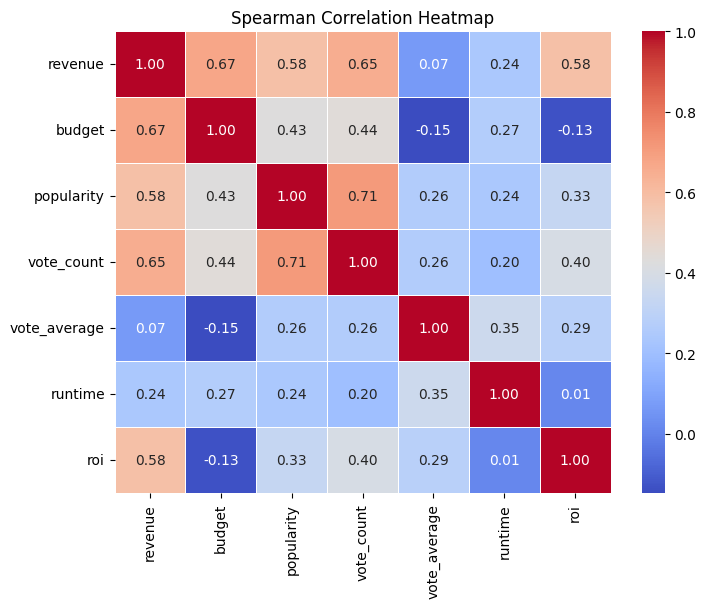

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(revenue_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Spearman Correlation Heatmap')
plt.show()

The Spearman correlation coefficient is 0.58, indicating a moderately positive correlation between the popularity and revenue.

The p-value is less than 0.05, meaning the correlation is statistically significant at the 5% significance level.

Revenue is most strongly associated with budget, vote count, and popularity, while vote average shows almost no relationship with revenue. This suggests that commercial success in the dataset is driven more by production scale and audience reach than by average viewer ratings. Runtime has only a weak association with revenue.
```
vote_count ↔ revenue = 0.65
Revenue is also strongly associated with audience engagement volume.
Movies with more votes tend to earn more.
popularity ↔ revenue = 0.58
More popular movies generally tend to have higher revenue as well.
```
**Important secondary insight** is vote_average is only very weakly related to revenue (0.07).


In [ ]:
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
# Pivot table by language

df.groupby('original_language').agg(
    median_revenue = ('revenue', 'median'),
    movie_count = ('id', 'count'),
    median_budget = ('budget', 'median'),
    median_popularity = ('popularity', 'median'),
    median_vote_count = ('vote_count', 'median'),
    median_vote_average = ('vote_average', 'median'),
    median_roi = ('roi', 'median')
).sort_values(by='median_revenue', ascending=False).head(10)


,median_revenue,movie_count,median_budget,median_popularity,median_vote_count,median_vote_average,median_roi
original_language,,,,,,,
te,160000000.00,3,31000000.00,4.78,909.00,7.52,261.11
zh,85882580.50,61,31000000.00,3.60,509.00,7.20,217.76
en,37575528.00,7947,20000000.00,2.97,1109.00,6.58,120.00
ar,35739050.00,2,4000000.00,2.83,1225.00,7.67,1524.47
hi,28430000.00,31,6663555.00,2.23,438.00,7.36,314.37
ko,21041950.00,94,8145000.00,3.41,652.00,7.40,296.54
th,20112926.00,12,1469584.50,2.91,624.00,7.12,1728.45
uk,17974964.00,2,3000000.00,4.44,851.00,7.39,259.50
lv,17660107.00,1,3700000.00,12.45,2695.00,8.09,377.30


```
te - Telugu
zh - Chinese
en - English
hi - Hindi
ja - Japanese
ko - Korean
ar - Arabic
cn - Cantonese
th - Thai
fr - French

In [ ]:
df[df['original_language'] == 'te']

,budget,id,origin_country,original_language,original_title,popularity,revenue,runtime,tagline,vote_average,vote_count,release_date,genres,production_company_name,budget_missing,revenue_missing,release_decade,roi,studio_list
3336,69000000.00,579974,IN,te,రౌద్రం రణం రుధిరం,7.57,160000000.00,185,"Rise, Roar, Revolt.",7.72,1555,2022-03-24,"[Action, Adventure, Drama]",DVV Entertainment,0,0,2020,131.88,[DVV Entertainment]
5097,25130430.00,256040,IN,te,బాహుబలి:ద బిగినింగ్,4.78,90747520.00,159,No Tagline,7.52,909,2015-07-10,"[Action, Drama]",Arka Media Works,0,0,2010,261.11,[Arka Media Works]
5375,31000000.00,350312,IN,te,బాహుబలి 2: ది కన్ క్లూజన్,3.40,280700000.00,167,No Tagline,7.46,835,2017-04-27,"[Action, Adventure, Fantasy]",Arka Media Works,0,0,2010,805.48,[Arka Media Works]


Manually made sure the revenue is real and not a mistake

In [ ]:
# By country

df.groupby('origin_country')['revenue'].median().sort_values(ascending=False).head(10)

,revenue
origin_country,
"FR, US, GB, MT",760006945.00
"DE, ES, GB, US",218366336.00
"DK, US",217515969.50
"HK, TW",213978518.00
"IS, GB, US",203427584.00
"BW, ZA",200000000.00
"DK, CA, AU, US",199603202.00
"DE, GB, US",195702811.00
"BG, CA, US, GB, PT",146661977.00


Multiple countries in origin_country means the film was a co-production — funded, filmed, or produced jointly by studios from multiple countries.

For example FR, US, GB, MT likely means a Hollywood-style film with French/British co-financing, shot partially in Malta for cost reasons.

In [ ]:
genre_revenue_summary = df_long.groupby('genres').agg(
    movie_count=('id', 'count'),
    median_revenue=('revenue', 'median'),
    median_budget=('budget', 'median'),
    median_popularity=('popularity', 'median'),
    median_vote_count=('vote_count', 'median'),
    median_vote_average=('vote_average', 'median')
).sort_values('movie_count', ascending=False)
genre_revenue_summary

,movie_count,median_revenue,median_budget,median_popularity,median_vote_count,median_vote_average
genres,,,,,,
Drama,4391,20061281.00,15000000.00,2.62,845.00,6.94
Comedy,3563,38073045.50,20000000.00,2.51,839.00,6.51
Thriller,2734,25317287.00,18000000.00,2.93,1037.00,6.44
Action,2325,58897907.00,34000000.00,3.74,1239.00,6.50
Adventure,1688,85564310.00,45000000.00,3.77,1541.00,6.67
Romance,1675,29196409.00,17000000.00,2.61,834.00,6.74
Crime,1578,27003571.50,20000000.00,2.90,975.00,6.68
Horror,1476,15362734.00,8000000.00,2.64,896.00,6.21
Science Fiction,1253,45490586.50,30000000.00,3.33,1288.00,6.48


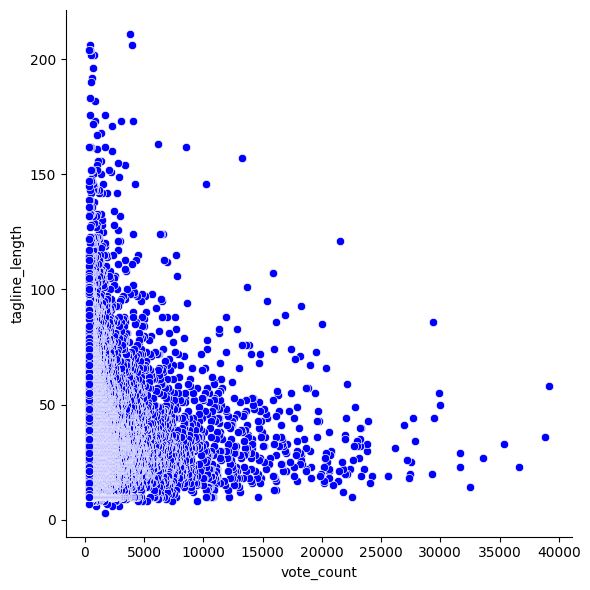

In [ ]:
df['tagline_length'] = df['tagline'].str.len()


sns.relplot(data=df,
            x = 'vote_count',
            y = 'tagline_length',
            color = 'blue',
            height=6,
            )



In [ ]:
spearmen_corr2 = df['vote_count'].corr(df['tagline_length'], method = 'spearman')
spearmen_corr2


np.float64(0.0838393382514231)

# Limitations

- The dataset contains **popular TMDB movies**, not a random sample of all films.
- `popularity` is a TMDB-specific metric, so it is less transparent than `vote_count`, `vote_average`, or `revenue`.
- Financial fields are incomplete and may not reflect full lifetime performance.
- Genre categories overlap.
- Country values may include co-productions, which can complicate country-level comparisons.
- Some language and country groups have very small sample sizes.
- Mean financial metrics can be strongly distorted by outliers, so medians are often more reliable.


## Main Findings So Far

### Audience engagement and revenue
- `vote_count` shows a strong positive relationship with `revenue`.
- Movies with more votes tend to generate higher revenue.
- This suggests that audience attention and commercial performance are closely related in the dataset.

### Revenue and budget
- `budget` shows one of the strongest positive relationships with `revenue`.
- Larger-budget movies tend to generate higher reported revenue.

### Vote average behaves differently
- `vote_average` has a much weaker relationship with `revenue` than `vote_count`.
- This suggests that average rating is less connected to commercial success than audience reach or engagement.

### Runtime has limited explanatory power
- Runtime shows only a weak relationship with revenue.
- Its relationship with audience evaluation is slightly stronger, but still limited.

### Genre-level interpretation requires caution
- Since one movie can belong to multiple genres, genre-level counts and percentages overlap.
- Genre analysis is still useful, but categories are not mutually exclusive.

### Financial metrics should be interpreted carefully
- `revenue` and `budget` in TMDB should not be treated as complete profit-and-loss data.
- A ratio such as `revenue / budget` is better interpreted as a **reported revenue-to-budget ratio**, not true profitability.
- Therefore, cases where `revenue < budget` should not automatically be interpreted as actual financial loss.

---

## Short Summary
This project explored a TMDB movie dataset in order to understand how movie metadata relates to audience engagement, ratings, and commercial performance. The work included data cleaning, exploratory analysis, genre parsing, summary tables, and correlation analysis. The strongest signals identified so far suggest that **vote_count** and **budget** are more strongly associated with **revenue** than `vote_average`, while some exploratory ideas such as tagline length did not show meaningful impact. The analysis provides a solid foundation for future Tableau dashboards and recommendation-oriented product thinking.
